# MLPR Project
## LSTM inference

This file uses the our trained LSTM model present in the `/model` for prediction and show the prediction for different day of the year

In [ ]:
# importing all libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import PowerTransformer, StandardScaler
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing

In [3]:
df = pd.read_csv('/kaggle/input/datasets/prajyotr/mlpr-project-dataset/dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

df['sr_wm2'] = df['sr_wm2'].clip(0, 1200)
df['sr_lag'] = df.groupby('station_id')['sr_wm2'].shift(1).fillna(0)
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour

train_mask = df['year'] < 2025
for col in ['station_id', 'state']:
    if col in df.columns:
        mapper = df.loc[train_mask].groupby(col)['sr_wm2'].mean().to_dict()
        df[f'{col}_avg'] = df[col].map(mapper).fillna(df.loc[train_mask, 'sr_wm2'].mean())

df['hour_sin'] = np.sin(df['hour'] * (2. * np.pi / 24)).astype('float32')
df['hour_cos'] = np.cos(df['hour'] * (2. * np.pi / 24)).astype('float32')

# Drop purely redundant columns 
cols_to_drop = ['at_c', 'rh_pct', 'ws_ms', 'wd_deg', 'rf_mm', 'station_id', 
                'station', 'state', 'city', 'era5_sw_down_wm2', 'hour', 'month']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

pt = PowerTransformer(method='yeo-johnson')
df['sr_wm2_scaled'] = pt.fit_transform(df[['sr_wm2']]).astype('float32')

FEATURES = [col for col in df.columns if col not in ['sr_wm2', 'sr_wm2_scaled', 'year', 'timestamp']]
test_df = df[df['year'] >= 2025].copy()
train_df = df[df['year'] < 2025].copy()

scaler = StandardScaler()
scaler.fit(train_df[FEATURES])
test_df[FEATURES] = scaler.transform(test_df[FEATURES]).astype('float32')

In [ ]:
def build_station_dataset(station_df, sequence_length, batch_size):
    station_datasets = []
    for _, grp in station_df.groupby('station_id_avg', sort=False):
        X = grp[FEATURES].values.astype('float32')
        y = grp['sr_wm2_scaled'].values.astype('float32')
        
        if len(X) <= sequence_length: continue

        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=X[:-sequence_length], targets=y[sequence_length:],
            sequence_length=sequence_length, batch_size=None, shuffle=False)
        
        station_datasets.append(ds)
    combined = station_datasets[0]
    for ds in station_datasets[1:]: combined = combined.concatenate(ds)
    return combined.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = build_station_dataset(test_df, 24, 256)

In [5]:
model = load_model('/kaggle/input/models/prajyotr/solar/keras/default/1/final_solar_lstm.keras')
y_pred_scaled = model.predict(val_ds)
y_true_scaled = np.concatenate([y for x, y in val_ds], axis=0)

y_true = pt.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
y_pred = pt.inverse_transform(y_pred_scaled).flatten()

I0000 00:00:1778883789.440055     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


3277/3277 ━━━━━━━━━━━━━━━━━━━━ 128s 38ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


### Predicting

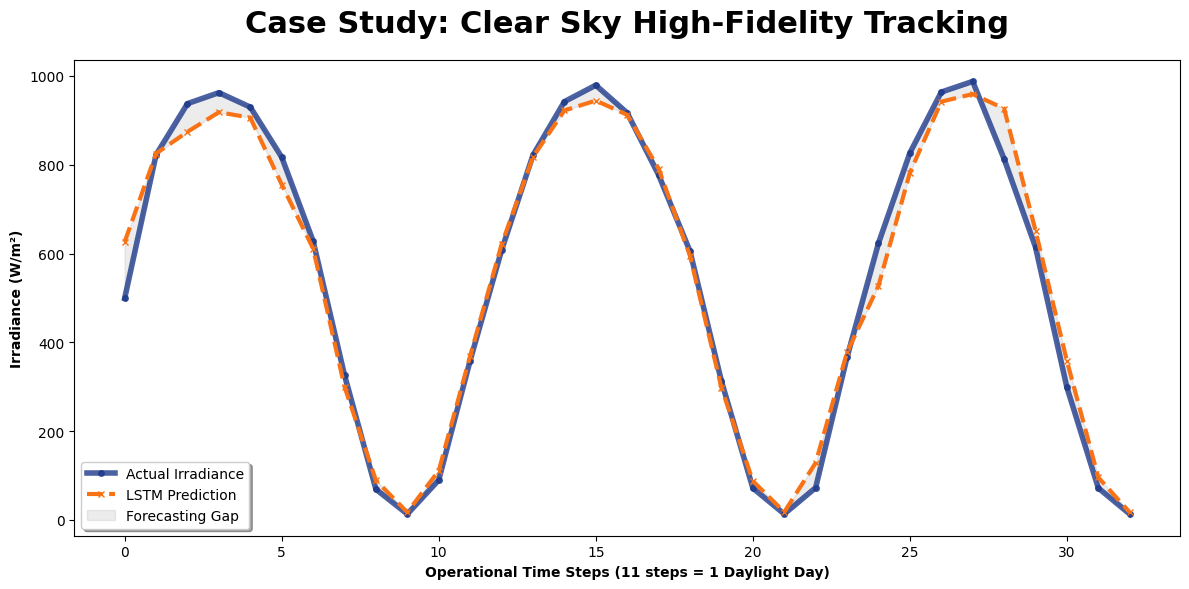

Saved: 1_Clear_Sky_3Days.png


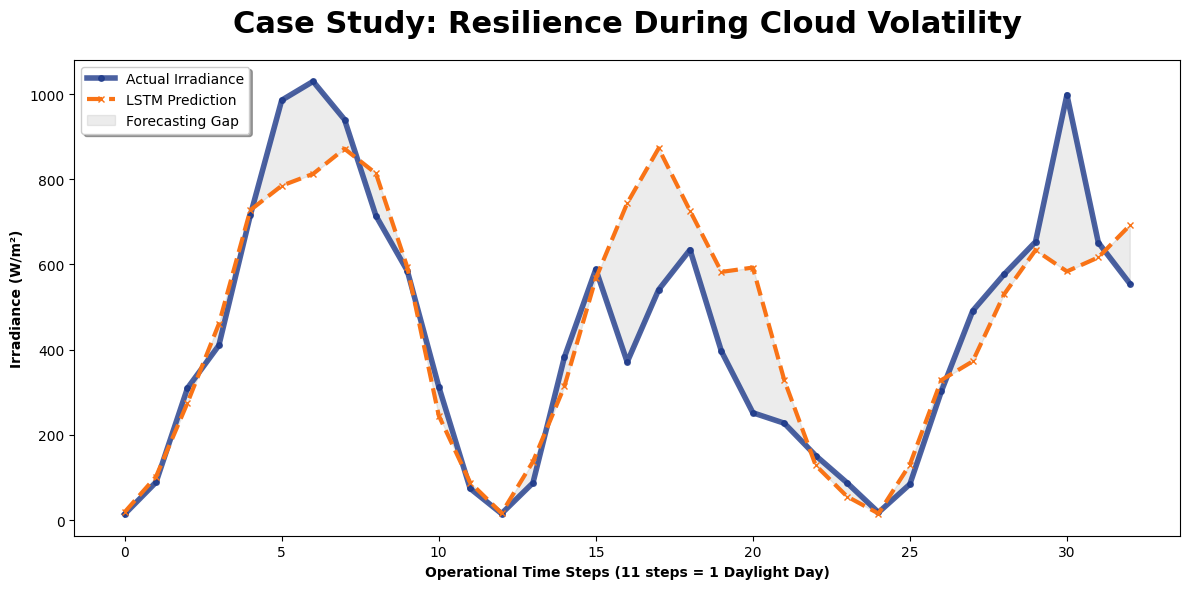

Saved: 2_Cloudy_Sky_3Days.png


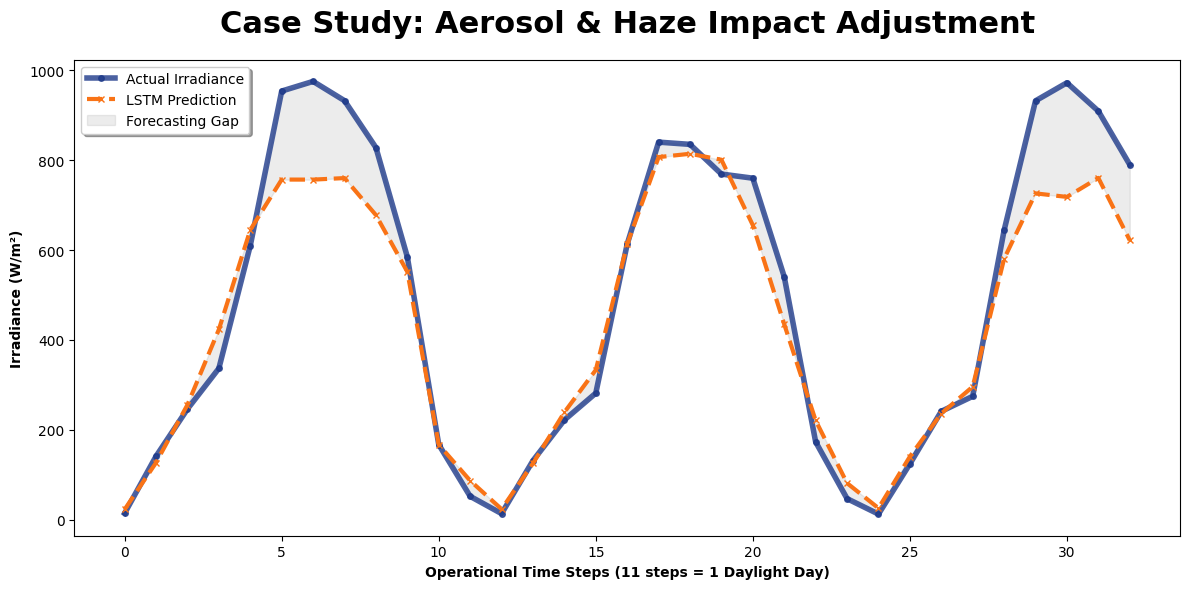

Saved: 3_Hazy_Sky_3Days.png


In [6]:
def plot_story_zoom(y_true, y_pred, start_idx, num_days=3, title="Case Study", filename="plot.png"):
    # 11 points per daylight day
    num_points = 11 * num_days
    
    plt.figure(figsize=(12, 6))
    
    truth = y_true[start_idx : start_idx + num_points]
    prediction = y_pred[start_idx : start_idx + num_points]
    
    plt.plot(truth, label='Actual Irradiance', color='#1e3a8a', linewidth=4, marker='o', markersize=4, alpha=0.8)
    plt.plot(prediction, label='LSTM Prediction', color='#f97316', linewidth=3, linestyle='--', marker='x', markersize=4)
    
    plt.fill_between(range(len(truth)), truth, prediction, color='gray', alpha=0.15, label='Forecasting Gap')
    
    plt.title(title, fontsize=22, fontweight='bold', pad=20)
    plt.xlabel(f"Operational Time Steps (11 steps = 1 Daylight Day)", fontweight='bold')
    plt.ylabel("Irradiance (W/m²)", fontweight='bold')
    plt.legend(frameon=True, shadow=True, facecolor='white')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"Saved: {filename}")


plot_story_zoom(y_true, y_pred, start_idx=220, num_days=3, 
                title="Case Study: Clear Sky High-Fidelity Tracking", 
                filename="1_Clear_Sky_3Days.png")

plot_story_zoom(y_true, y_pred, start_idx=450, num_days=3, 
                title="Case Study: Resilience During Cloud Volatility", 
                filename="2_Cloudy_Sky_3Days.png")

plot_story_zoom(y_true, y_pred, start_idx=800, num_days=3, 
                title="Case Study: Aerosol & Haze Impact Adjustment", 
                filename="3_Hazy_Sky_3Days.png")